# CorrDiff for Toy Meteorological Downscaling with NOAA GFS

This notebook introduces the core idea behind **CorrDiff** (https://arxiv.org/pdf/2309.15214) using a deliberately small in-class example built from the **NOAA GFS analysis** archive hosted by dynamical.org.

The real CorrDiff paper studies kilometer-scale atmospheric downscaling with a **two-stage model**: first a deterministic regression model predicts the mean high-resolution state, then a conditional diffusion model stochastically corrects that mean by generating plausible fine-scale residual structure. Here we reproduce that logic in miniature.

This notebook is **not a reproduction of the full paper**. The simplifications are substantial:

- we use a tiny spatial subset of the GFS analysis archive,
- we use only a single field (`temperature_2m`),
- our "low-resolution" inputs are created by **synthetically coarsening** the native 0.25 degree field,
- we train only on a very small number of timestamps so the notebook runs in class,
- the diffusion model is a very small conditional CNN rather than the production CorrDiff architecture.

The purpose is conceptual clarity: understand the **residual corrective diffusion** idea on a real meteorological grid before moving to larger multivariate setups.

This notebook was designed to run from the project virtual environment at `.venv`.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(7)
torch.manual_seed(7)

device = torch.device('cpu')
device


device(type='cpu')

## 1. What CorrDiff does

The CorrDiff paper proposes a **two-step residual correction strategy** for atmospheric downscaling.

Let $\mathbf{y}$ denote the coarse-resolution atmospheric input and $\mathbf{x}$ the target high-resolution field. Instead of learning $p(\mathbf{x}\mid\mathbf{y})$ directly with one large diffusion model, CorrDiff decomposes the problem into:

1. a deterministic mean model

$$
\boldsymbol{\mu}_\theta(\mathbf{y}) \approx \mathbb{E}[\mathbf{x}\mid\mathbf{y}],
$$

2. a diffusion model for the residual

$$
\mathbf{r} = \mathbf{x} - \boldsymbol{\mu}_\theta(\mathbf{y}).
$$

The final sample is then

$$
\hat{\mathbf{x}} = \boldsymbol{\mu}_\theta(\mathbf{y}) + \hat{\mathbf{r}}.
$$

This split is physically and statistically useful. Large-scale structure and predictable mean corrections are handled by the fast deterministic model, while the diffusion model focuses only on the unresolved residual variability.

In the published CorrDiff work, this idea is used for **25 km to 2 km atmospheric downscaling over Taiwan**, with a regression model for the mean followed by a diffusion model that restores sharp small-scale structure and probabilistic spread. Our notebook keeps that logic but shrinks everything to a toy single-variable problem.


## 2. Data source and toy setup

We use the **NOAA GFS analysis** archive from dynamical.org. The catalog page documents this dataset as:

- global spatial domain,
- 0.25 degree spatial resolution,
- hourly temporal resolution,
- time coverage from 2021-05-01 00:00 UTC to present.

The direct access pattern is:

```python
xr.open_zarr("https://data.dynamical.org/noaa/gfs/analysis/latest.zarr")
```

For class use we take only:

- one variable: `temperature_2m`,
- a tiny 32 x 32 patch over the western United States,
- timestamps every 6 hours over a short date range.

The inputs are **not** true coarse-resolution model output. Instead, we synthetically create coarse fields by block-averaging the native-resolution target and then bilinearly interpolating back to the original grid. That makes this a controlled super-resolution exercise rather than a full operational downscaling workflow.


In [2]:
DATA_URL = "https://data.dynamical.org/noaa/gfs/analysis/latest.zarr"
VARIABLE = "temperature_2m"

START_DATE = "2025-01-01"
END_DATE   = "2025-01-12"

# This box gives exactly 32 x 32 grid cells at 0.25 degree spacing.
LAT_NORTH, LAT_SOUTH = 39.75, 32.0
LON_WEST,  LON_EAST  = -119.75, -112.0

TIME_STRIDE_HOURS = 6
DOWNSAMPLE_FACTOR = 4
TRAIN_FRACTION = 0.80

BATCH_SIZE = 8
MEAN_EPOCHS = 12
DIFF_EPOCHS = 15
LEARNING_RATE = 1e-3
N_DIFFUSION_STEPS = 24


In [3]:
ds = xr.open_zarr(DATA_URL)[[VARIABLE]]

subset = (
    ds.sel(
        time=slice(START_DATE, END_DATE),
        latitude=slice(LAT_NORTH, LAT_SOUTH),
        longitude=slice(LON_WEST, LON_EAST),
    )
    .isel(time=slice(None, None, TIME_STRIDE_HOURS))
    .load()
)

times = subset.time.values
lat = subset.latitude.values
lon = subset.longitude.values
field = subset[VARIABLE].values.astype(np.float32)

print(subset)
print(f"Field array shape: {field.shape} = (time, lat, lon)")
print(f"Date range: {np.datetime_as_string(times[0], unit='h')} to {np.datetime_as_string(times[-1], unit='h')}")


<xarray.Dataset> Size: 198kB
Dimensions:         (time: 48, latitude: 32, longitude: 32)
Coordinates:
  * time            (time) datetime64[ns] 384B 2025-01-01 ... 2025-01-12T18:0...
  * latitude        (latitude) float64 256B 39.75 39.5 39.25 ... 32.5 32.25 32.0
  * longitude       (longitude) float64 256B -119.8 -119.5 ... -112.2 -112.0
    spatial_ref     int64 8B 0
Data variables:
    temperature_2m  (time, latitude, longitude) float32 197kB 1.234 ... 12.25
Attributes:
    dataset_id:          noaa-gfs-analysis
    dataset_version:     0.1.0
    name:                NOAA GFS analysis
    description:         Weather analysis from the Global Forecast System (GF...
    attribution:         NOAA NWS NCEP GFS data processed by dynamical.org fr...
    spatial_domain:      Global
    spatial_resolution:  0.25 degrees (~20km)
    time_domain:         2021-05-01 00:00:00 UTC to Present
    time_resolution:     1 hour
Field array shape: (48, 32, 32) = (time, lat, lon)
Date range: 2025-01-01

## 3. Build a synthetic low-resolution input

The original CorrDiff problem maps genuinely coarse atmospheric inputs to a higher-resolution target. We do not have a paired coarse and fine archive here, so we mimic that setup by degrading the native field.

Given a native-resolution target field $\mathbf{x}$, we create a coarse observation $\mathbf{y}$ in two steps:

1. average over non-overlapping $4 \times 4$ blocks,
2. bilinearly interpolate the coarse grid back to the original resolution.

The interpolated field keeps the large-scale pattern but loses much of the fine structure. That makes it a natural conditioning input for a corrective model.


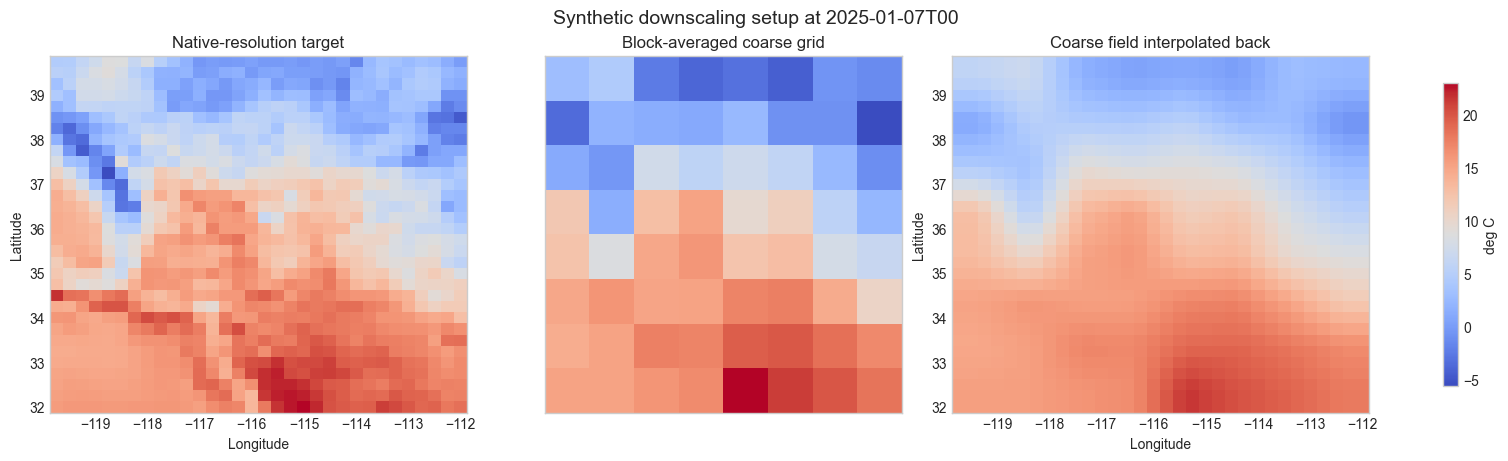

In [4]:
def synthetic_coarsen(field, factor=4):
    x = torch.tensor(field[:, None])
    coarse = F.avg_pool2d(x, kernel_size=factor, stride=factor)
    coarse_up = F.interpolate(coarse, size=x.shape[-2:], mode='bilinear', align_corners=False)
    return coarse[:, 0].numpy(), coarse_up[:, 0].numpy()

coarse, coarse_up = synthetic_coarsen(field, factor=DOWNSAMPLE_FACTOR)

sample_idx = len(times) // 2
sample_time = np.datetime_as_string(times[sample_idx], unit='h')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
vmin = min(field[sample_idx].min(), coarse_up[sample_idx].min())
vmax = max(field[sample_idx].max(), coarse_up[sample_idx].max())

pcm0 = axes[0].pcolormesh(lon, lat, field[sample_idx], shading='auto', cmap='coolwarm', vmin=vmin, vmax=vmax)
axes[0].set_title('Native-resolution target')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

pcm1 = axes[1].imshow(coarse[sample_idx], origin='upper', cmap='coolwarm')
axes[1].set_title('Block-averaged coarse grid')
axes[1].set_xticks([])
axes[1].set_yticks([])

pcm2 = axes[2].pcolormesh(lon, lat, coarse_up[sample_idx], shading='auto', cmap='coolwarm', vmin=vmin, vmax=vmax)
axes[2].set_title('Coarse field interpolated back')
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')

fig.colorbar(pcm0, ax=axes, shrink=0.85, label='deg C')
fig.suptitle(f'Synthetic downscaling setup at {sample_time}', fontsize=14)
plt.show()


## 4. Build training and validation sets

Each timestamp is treated as one independent downscaling sample.

We use a **temporal split** rather than a random shuffle. That is not as important here as in forecasting, but it still avoids mixing neighboring times between train and validation.

We standardize using the training portion only:

$$
\tilde{\mathbf{x}} = \frac{\mathbf{x} - \mu_{\mathrm{train}}}{\sigma_{\mathrm{train}}}.
$$

Because the coarse and high-resolution fields are the same physical variable, we normalize both with the same target statistics.


In [5]:
split_idx = int(TRAIN_FRACTION * len(field))

train_mean = field[:split_idx].mean()
train_std = field[:split_idx].std() + 1e-6

field_norm = (field - train_mean) / train_std
coarse_norm = (coarse_up - train_mean) / train_std

X_train = torch.tensor(coarse_norm[:split_idx, None], dtype=torch.float32)
y_train = torch.tensor(field_norm[:split_idx, None], dtype=torch.float32)
X_val = torch.tensor(coarse_norm[split_idx:, None], dtype=torch.float32)
y_val = torch.tensor(field_norm[split_idx:, None], dtype=torch.float32)
times_val = times[split_idx:]

print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Grid shape:         {X_train.shape[-2:]} (H, W)")


Training samples:   38
Validation samples: 10
Grid shape:         torch.Size([32, 32]) (H, W)


## 5. Stage 1: deterministic mean model

In CorrDiff, the first stage predicts a deterministic mean state $\boldsymbol{\mu}_\theta(\mathbf{y})$. For our toy setup we use a very small convolutional network that predicts a **correction** to the interpolated coarse field rather than a full field from scratch:

$$
\boldsymbol{\mu}_\theta(\mathbf{y}) = \mathbf{y} + c_\theta(\mathbf{y}).
$$

This is a good inductive bias because the coarse interpolation already contains the large scales; the network only needs to learn how to sharpen and bias-correct it.

We train the mean model with mean-squared error on the normalized target field. We also compare it against the interpolated coarse field itself, which serves as a baseline.


epoch  1 | mean-model loss = 0.0629
epoch  2 | mean-model loss = 0.0583
epoch  3 | mean-model loss = 0.0546
epoch  4 | mean-model loss = 0.0530
epoch  5 | mean-model loss = 0.0511
epoch  6 | mean-model loss = 0.0500
epoch  7 | mean-model loss = 0.0490
epoch  8 | mean-model loss = 0.0482
epoch  9 | mean-model loss = 0.0477
epoch 10 | mean-model loss = 0.0468
epoch 11 | mean-model loss = 0.0464
epoch 12 | mean-model loss = 0.0463

Interpolated coarse baseline RMSE: 1.809 deg C
Mean-model RMSE:                  1.504 deg C


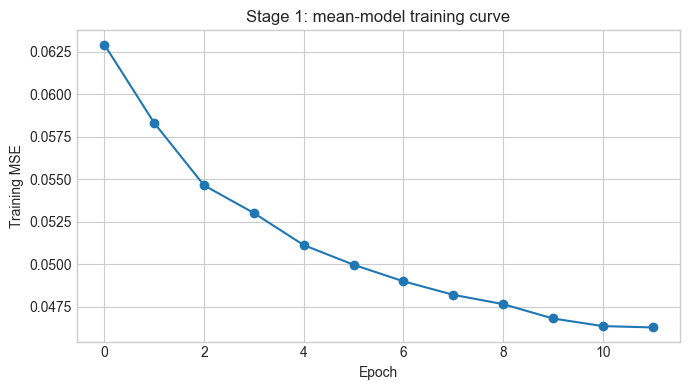

In [6]:
class ResidualMeanModel(nn.Module):
    def __init__(self, width=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, width, kernel_size=5, padding=2),
            nn.GELU(),
            nn.Conv2d(width, width, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(width, width, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(width, 1, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return x + self.net(x)


mean_model = ResidualMeanModel().to(device)
optimizer = torch.optim.Adam(mean_model.parameters(), lr=LEARNING_RATE)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)

mean_loss_history = []
for epoch in range(MEAN_EPOCHS):
    mean_model.train()
    running = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        pred = mean_model(xb)
        loss = F.mse_loss(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running += loss.item() * xb.size(0)

    mean_loss_history.append(running / len(X_train))
    print(f"epoch {epoch + 1:2d} | mean-model loss = {mean_loss_history[-1]:.4f}")

with torch.no_grad():
    mean_model.eval()
    mean_pred_train = mean_model(X_train.to(device)).cpu()
    mean_pred_val = mean_model(X_val.to(device)).cpu()

baseline_rmse = torch.sqrt(F.mse_loss(X_val, y_val)).item() * train_std
mean_model_rmse = torch.sqrt(F.mse_loss(mean_pred_val, y_val)).item() * train_std

print(f"\nInterpolated coarse baseline RMSE: {baseline_rmse:.3f} deg C")
print(f"Mean-model RMSE:                  {mean_model_rmse:.3f} deg C")

plt.figure(figsize=(7, 4))
plt.plot(mean_loss_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training MSE')
plt.title('Stage 1: mean-model training curve')
plt.tight_layout()
plt.show()


## 6. Stage 2: residual diffusion model

Now define the residual in normalized units:

$$
\mathbf{r} = \tilde{\mathbf{x}} - \boldsymbol{\mu}_\theta(\tilde{\mathbf{y}}).
$$

The diffusion model does not generate the whole high-resolution field. It generates only the unresolved correction. This is the main CorrDiff idea.

We train a small conditional DDPM on the residual. At diffusion step $t$ we corrupt the clean residual $\mathbf{r}_0$ with Gaussian noise:

$$
\mathbf{r}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{r}_0 + \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon},
$$

and train a network to predict the injected noise:

$$
\boldsymbol{\epsilon}_\phi(\mathbf{r}_t, \tilde{\mathbf{y}}, \boldsymbol{\mu}_\theta(\tilde{\mathbf{y}}), t) \approx \boldsymbol{\epsilon}.
$$

Conditioning on both the coarse input and the deterministic mean gives the diffusion model the large-scale context it needs. The diffusion model can then spend its capacity on the residual fine structure rather than relearning the entire state.

A useful clarification: **a diffusion model is not identified by a special standalone neural-network type**. The network is only the denoiser or score model inside the larger stochastic construction. What makes the model a diffusion model is:

- the forward noising process,
- the timestep-conditioned noise-prediction objective,
- the reverse-time sampling procedure.

For gridded meteorological fields, a CNN is a natural backbone because the data are spatial and translation-structured. To make that structure more explicit, below we use a tiny **time-conditioned U-Net-like denoiser** together with explicit `q_sample` and reverse `p_sample` functions. So the backbone is still convolutional, but the code now makes the DDPM machinery much more visible.


epoch  1 | diffusion loss = 1.5173
epoch  2 | diffusion loss = 0.9708
epoch  3 | diffusion loss = 0.9247
epoch  4 | diffusion loss = 0.9232
epoch  5 | diffusion loss = 0.9050
epoch  6 | diffusion loss = 0.8563
epoch  7 | diffusion loss = 0.8678
epoch  8 | diffusion loss = 0.8392
epoch  9 | diffusion loss = 0.8677
epoch 10 | diffusion loss = 0.8699
epoch 11 | diffusion loss = 0.8442
epoch 12 | diffusion loss = 0.8266
epoch 13 | diffusion loss = 0.7861
epoch 14 | diffusion loss = 0.8232
epoch 15 | diffusion loss = 0.7900


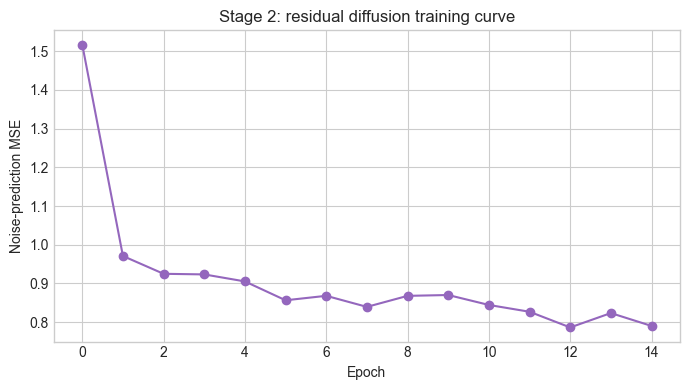

In [12]:
resid_train = y_train - mean_pred_train
resid_val = y_val - mean_pred_val
resid_std = resid_train.std().item() + 1e-6

resid_train_scaled = resid_train / resid_std
resid_val_scaled = resid_val / resid_std

betas = torch.linspace(1e-4, 2e-2, N_DIFFUSION_STEPS, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)


def q_sample(r0, t, noise):
    alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1)
    return torch.sqrt(alpha_bar_t) * r0 + torch.sqrt(1 - alpha_bar_t) * noise


class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, embed_dim=64):
        super().__init__()
        self.embed_dim = embed_dim

    def forward(self, t):
        half_dim = self.embed_dim // 2
        freqs = torch.exp(
            -np.log(10000.0) * torch.arange(half_dim, device=t.device).float() / max(half_dim - 1, 1)
        )
        angles = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        emb = torch.cat([torch.sin(angles), torch.cos(angles)], dim=1)
        if self.embed_dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


class TimeResidualBlock(nn.Module):
    def __init__(self, channels, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(4, channels)
        self.norm2 = nn.GroupNorm(4, channels)
        self.time_proj = nn.Linear(time_dim, channels)

    def forward(self, x, t_emb):
        h = self.conv1(F.gelu(self.norm1(x)))
        h = h + self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = self.conv2(F.gelu(self.norm2(h)))
        return x + h


class TinyConditionalUNet(nn.Module):
    def __init__(self, in_channels=3, width=32, time_dim=64):
        super().__init__()
        self.time_embed = SinusoidalTimeEmbedding(time_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )
        self.in_proj = nn.Conv2d(in_channels, width, kernel_size=3, padding=1)
        self.enc_block = TimeResidualBlock(width, time_dim)
        self.down = nn.Conv2d(width, 2 * width, kernel_size=4, stride=2, padding=1)
        self.mid_block = TimeResidualBlock(2 * width, time_dim)
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(2 * width, width, kernel_size=3, padding=1),
        )
        self.dec_block = TimeResidualBlock(width, time_dim)
        self.out_proj = nn.Conv2d(width, 1, kernel_size=3, padding=1)

    def forward(self, r_t, coarse_field, mean_field, t):
        t_emb = self.time_mlp(self.time_embed(t))
        x = torch.cat([r_t, coarse_field, mean_field], dim=1)
        h1 = self.enc_block(self.in_proj(x), t_emb)
        h2 = self.mid_block(self.down(h1), t_emb)
        h3 = self.up(h2)
        h = self.dec_block(h3 + h1, t_emb)
        return self.out_proj(h)


diff_model = TinyConditionalUNet().to(device)
optimizer = torch.optim.Adam(diff_model.parameters(), lr=LEARNING_RATE)

X_train_d = X_train.to(device)
X_val_d = X_val.to(device)
mean_pred_train_d = mean_pred_train.to(device)
mean_pred_val_d = mean_pred_val.to(device)
resid_train_scaled_d = resid_train_scaled.to(device)

diff_loss_history = []
n_train = len(X_train_d)

for epoch in range(DIFF_EPOCHS):
    diff_model.train()
    order = torch.randperm(n_train)
    running = 0.0

    for start in range(0, n_train, BATCH_SIZE):
        idx = order[start:start + BATCH_SIZE]

        r0 = resid_train_scaled_d[idx]
        coarse_batch = X_train_d[idx]
        mean_batch = mean_pred_train_d[idx]
        t = torch.randint(0, N_DIFFUSION_STEPS, (len(idx),), device=device)
        noise = torch.randn_like(r0)
        r_t = q_sample(r0, t, noise)

        pred_noise = diff_model(r_t, coarse_batch, mean_batch, t)
        loss = F.mse_loss(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running += loss.item() * len(idx)

    diff_loss_history.append(running / n_train)
    print(f"epoch {epoch + 1:2d} | diffusion loss = {diff_loss_history[-1]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(diff_loss_history, marker='o', color='tab:purple')
plt.xlabel('Epoch')
plt.ylabel('Noise-prediction MSE')
plt.title('Stage 2: residual diffusion training curve')
plt.tight_layout()
plt.show()


## 7. Sampling a CorrDiff-style correction

At inference time the workflow is:

1. take a coarse field $\tilde{\mathbf{y}}$,
2. compute the deterministic mean $\boldsymbol{\mu}_\theta(\tilde{\mathbf{y}})$,
3. sample a residual $\hat{\mathbf{r}}$ with the conditional diffusion model,
4. reconstruct the high-resolution sample:

$$
\hat{\mathbf{x}} = \boldsymbol{\mu}_\theta(\tilde{\mathbf{y}}) + \hat{\mathbf{r}}.
$$

Because the residual is generated stochastically, the same coarse input can produce an **ensemble** of plausible high-resolution outputs. That is the probabilistic part of CorrDiff.

On this toy example we should not expect production-quality calibration or spectacular gains. The point is to see the model hierarchy clearly: coarse field, deterministic mean, then stochastic correction.


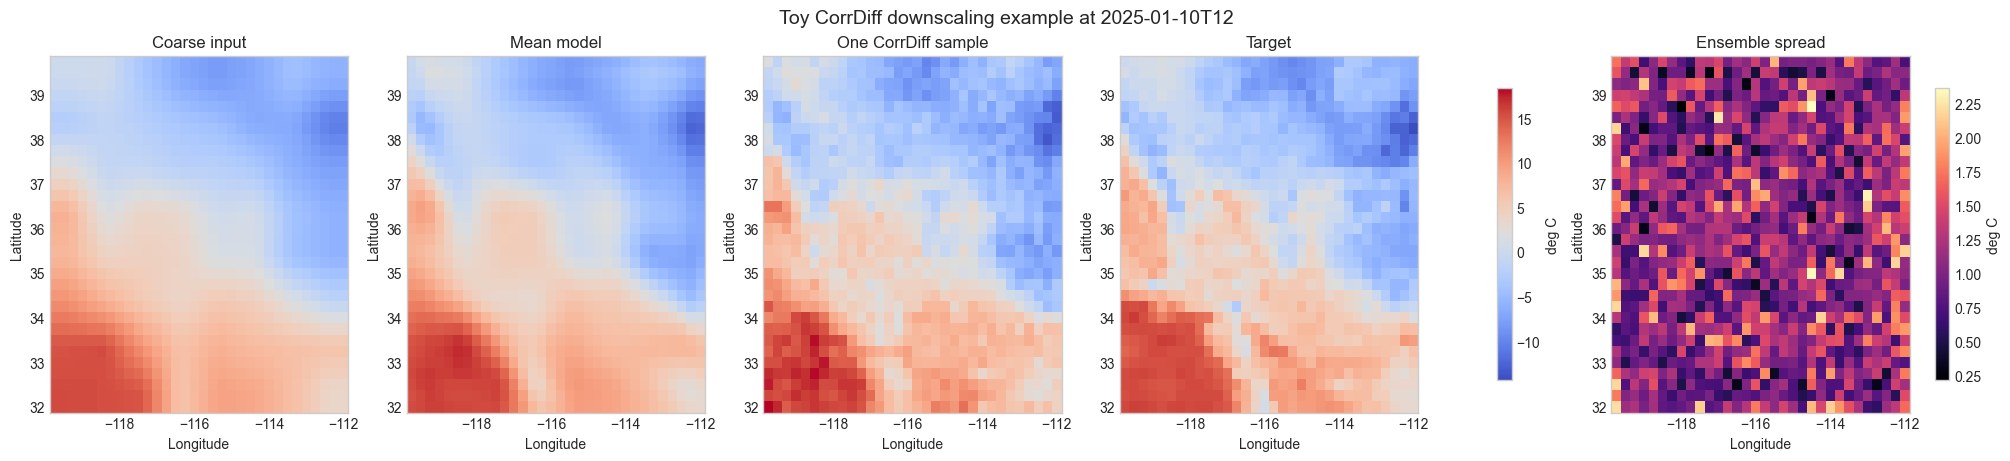

Case-study deterministic mean RMSE: 1.485 deg C
Case-study one-sample CorrDiff RMSE: 1.902 deg C
Note: a stochastic sample need not beat the deterministic mean in RMSE; its job is to produce plausible fine-scale variability and ensemble spread.


In [13]:
@torch.no_grad()
def p_sample(diff_model, r_t, coarse_field, mean_field, t):
    t_batch = torch.full((r_t.shape[0],), t, device=device, dtype=torch.long)
    eps = diff_model(r_t, coarse_field, mean_field, t_batch)

    alpha_t = alphas[t]
    alpha_bar_t = alpha_bars[t]
    beta_t = betas[t]

    mean = (1.0 / torch.sqrt(alpha_t)) * (r_t - (beta_t / torch.sqrt(1 - alpha_bar_t)) * eps)

    if t > 0:
        return mean + torch.sqrt(beta_t) * torch.randn_like(r_t)
    return mean


@torch.no_grad()
def sample_residual(diff_model, coarse_field, mean_field):
    r_t = torch.randn_like(mean_field)
    for t in reversed(range(N_DIFFUSION_STEPS)):
        r_t = p_sample(diff_model, r_t, coarse_field, mean_field, t)
    return r_t


case_idx = 0
coarse_case = X_val_d[case_idx:case_idx+1]
mean_case = mean_pred_val_d[case_idx:case_idx+1]
truth_case = y_val[case_idx:case_idx+1]

ensemble_size = 6
samples_norm = []
for _ in range(ensemble_size):
    resid_sample = sample_residual(diff_model, coarse_case, mean_case)
    sample_norm = mean_case + resid_sample * resid_std
    samples_norm.append(sample_norm.cpu())

samples_norm = torch.cat(samples_norm, dim=0)
ensemble_mean = samples_norm.mean(dim=0, keepdim=True)
ensemble_std = samples_norm.std(dim=0, keepdim=True)

coarse_case_phys = coarse_case.cpu().numpy()[0, 0] * train_std + train_mean
mean_case_phys = mean_case.cpu().numpy()[0, 0] * train_std + train_mean
sample_case_phys = samples_norm[0, 0].numpy() * train_std + train_mean
truth_case_phys = truth_case.numpy()[0, 0] * train_std + train_mean
spread_case_phys = ensemble_std[0, 0].numpy() * train_std

case_time = np.datetime_as_string(times_val[case_idx], unit='h')
vmin = min(truth_case_phys.min(), coarse_case_phys.min(), mean_case_phys.min(), sample_case_phys.min())
vmax = max(truth_case_phys.max(), coarse_case_phys.max(), mean_case_phys.max(), sample_case_phys.max())

fig, axes = plt.subplots(1, 5, figsize=(20, 4.5), constrained_layout=True)

for ax, arr, title in [
    (axes[0], coarse_case_phys, 'Coarse input'),
    (axes[1], mean_case_phys, 'Mean model'),
    (axes[2], sample_case_phys, 'One CorrDiff sample'),
    (axes[3], truth_case_phys, 'Target'),
]:
    pcm = ax.pcolormesh(lon, lat, arr, shading='auto', cmap='coolwarm', vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

pcm_spread = axes[4].pcolormesh(lon, lat, spread_case_phys, shading='auto', cmap='magma')
axes[4].set_title('Ensemble spread')
axes[4].set_xlabel('Longitude')
axes[4].set_ylabel('Latitude')

fig.colorbar(pcm, ax=axes[:4], shrink=0.82, label='deg C')
fig.colorbar(pcm_spread, ax=axes[4], shrink=0.82, label='deg C')
fig.suptitle(f'Toy CorrDiff downscaling example at {case_time}', fontsize=14)
plt.show()

sample_rmse = torch.sqrt(torch.mean((samples_norm[0:1] - truth_case) ** 2)).item() * train_std
mean_rmse_case = torch.sqrt(torch.mean((mean_case.cpu() - truth_case) ** 2)).item() * train_std

print(f"Case-study deterministic mean RMSE: {mean_rmse_case:.3f} deg C")
print(f"Case-study one-sample CorrDiff RMSE: {sample_rmse:.3f} deg C")
print("Note: a stochastic sample need not beat the deterministic mean in RMSE; its job is to produce plausible fine-scale variability and ensemble spread.")


## 8. Inspect the ensemble members directly

The previous figure showed one stochastic sample and the ensemble spread. It is also useful to inspect the ensemble members themselves. In a residual diffusion model, different samples should share the same large-scale temperature pattern inherited from the conditioning field while differing in their fine-scale corrective structure.


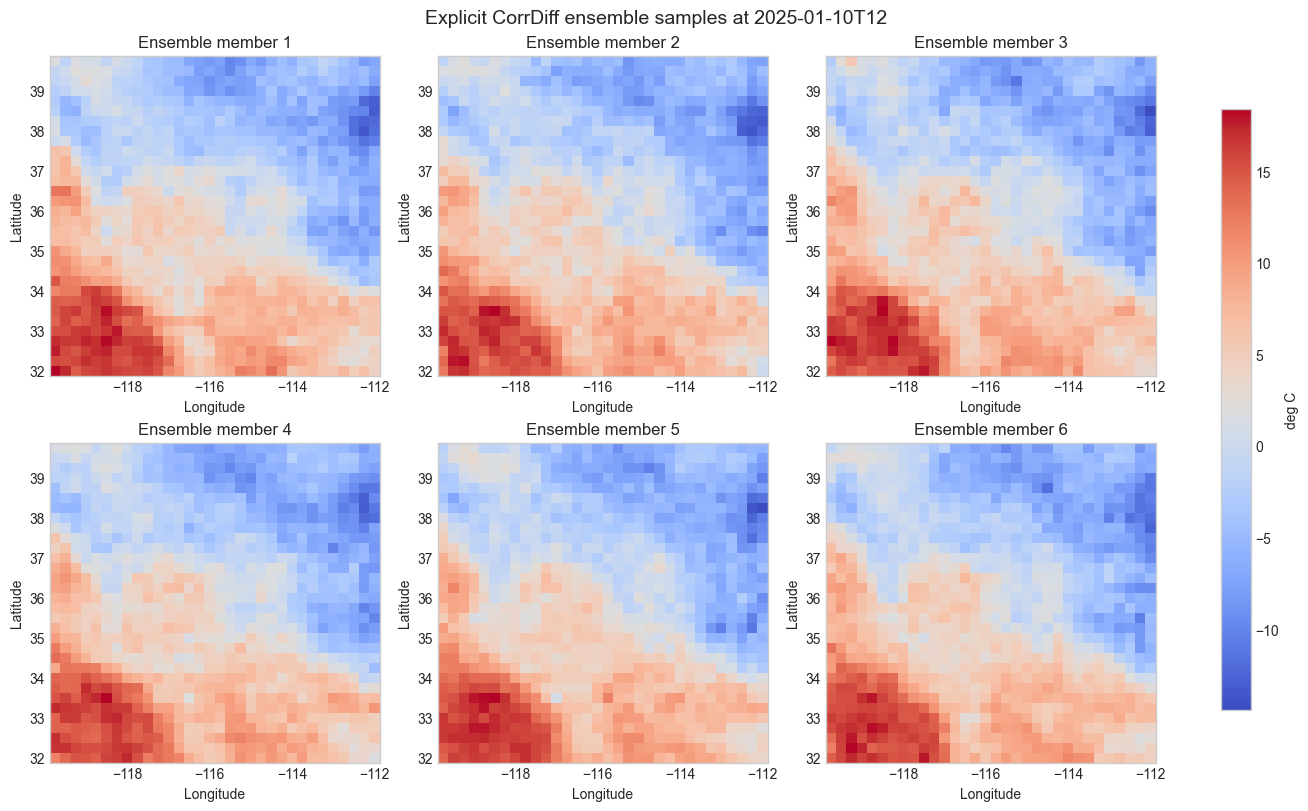

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
axes = axes.ravel()

for i, ax in enumerate(axes):
    member = samples_norm[i, 0].numpy() * train_std + train_mean
    pcm = ax.pcolormesh(lon, lat, member, shading='auto', cmap='coolwarm', vmin=vmin, vmax=vmax)
    ax.set_title(f'Ensemble member {i + 1}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

fig.colorbar(pcm, ax=axes, shrink=0.85, label='deg C')
fig.suptitle(f'Explicit CorrDiff ensemble samples at {case_time}', fontsize=14)
plt.show()


## 9. What this toy notebook captures

This notebook reproduces the **logic** of CorrDiff without reproducing the full paper setup:

- a coarse meteorological input is used to predict a deterministic mean field,
- a diffusion model is trained only on the residual correction,
- the final downscaled field is the sum of the mean and a stochastic residual sample.

That decomposition is the key idea behind CorrDiff. In the real model, the conditioning is multivariate, the target resolution jump is much larger, the network architecture is much more expressive, and the generated fields are judged not just by pointwise errors but also by spectra, distributions, and the realism of coherent weather structures.

For class, though, this toy example is enough to make the method concrete. It shows how diffusion can be used not to generate an entire geophysical state from scratch, but to **correct the residual fine-scale information missing from a deterministic downscaling model**.
